In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

In [3]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
368,1,3,female,28.0,0,0,7.7500,Q
570,1,2,male,62.0,0,0,10.5000,S
635,1,2,female,28.0,0,0,13.0000,S
501,0,3,female,21.0,0,0,7.7500,Q
870,0,3,male,26.0,0,0,7.8958,S


In [4]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

In [5]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
252,0,1,1,62.0,0,0,26.5500,2
373,0,1,1,22.0,0,0,135.6333,0
156,1,3,0,16.0,0,0,7.7333,1
292,0,2,1,36.0,0,0,12.8750,0
324,0,3,1,28.0,8,2,69.5500,2


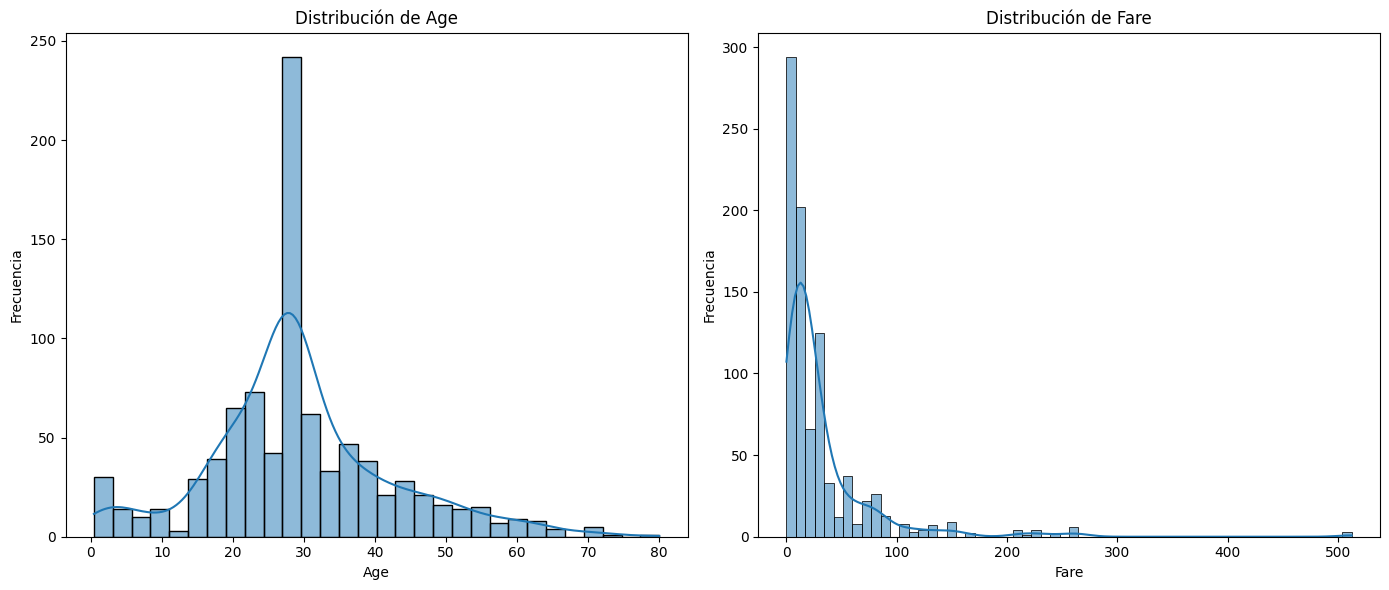

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [7]:
qun_tra_age = QuantileTransformer(output_distribution='normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution='normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

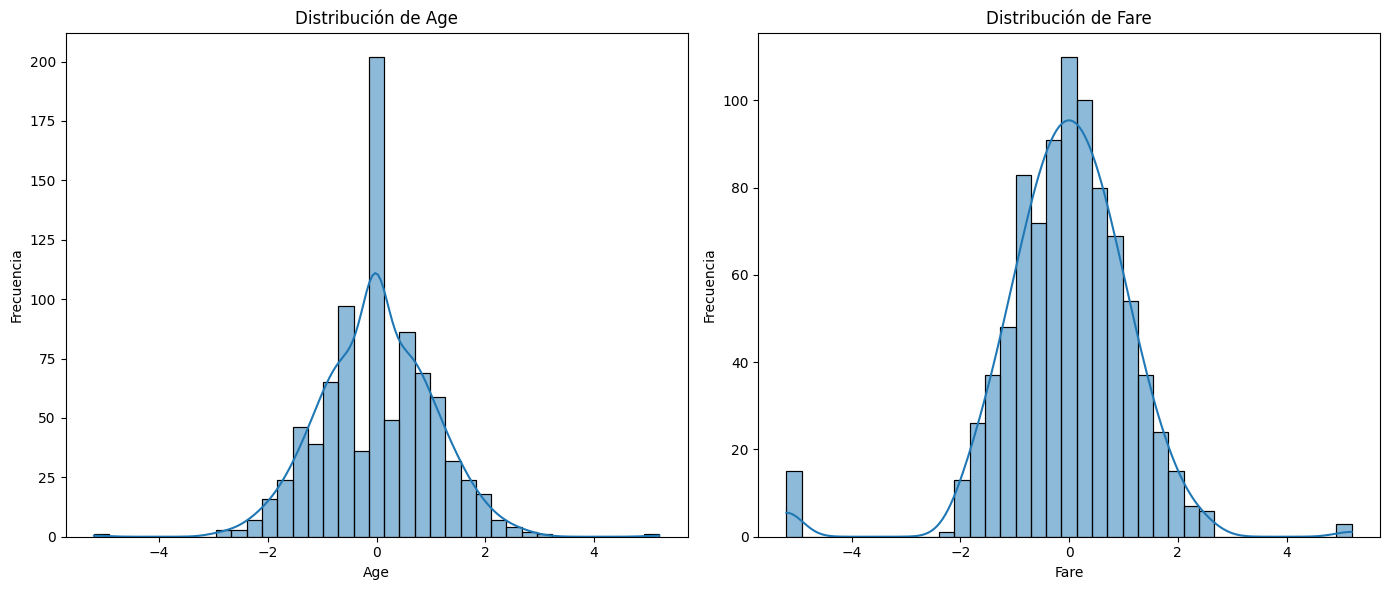

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [9]:
mms_pclass = MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [10]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
255,1,1.0,0.0,0.528932,0.000,0.333333,0.504833,0.0
338,1,1.0,1.0,0.612399,0.000,0.000000,0.448347,1.0
73,0,1.0,1.0,0.462346,0.125,0.000000,0.499517,0.0
851,0,1.0,1.0,0.786603,0.000,0.000000,0.406451,1.0
214,0,1.0,1.0,0.497826,0.125,0.000000,0.394924,0.5


In [11]:
df.to_csv('./data/titanic_procesado.csv', index=False)

In [12]:
import os

os.listdir('./data')

['titanic.csv', 'titanic_clean.csv', 'titanic_procesado.csv']